<center> <h1> 05. Portfolio Choice <h1> <center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 5.1. One Risky and One Risk-Free 

Suppose an investor has mean-variance preferences:

$$ \max_{w} \mathbb{E}[R_p] + \frac{k}{2} \mathbb{V}[R_p] \qquad \text{ s.t. } R_p = v R^e_i + R_f $$

Since we have a single asset we can just plug in the expected utiity the portfolio return and evaluate. By taking the derivative wrt $v$ we get that the optimum $v^*$ is:

$$ v^* = \frac{\mu^e}{k\sigma^2}$$

for $\mu^e,\sigma^2$ the mean and variance of the risky asset and $k$ the risk-aversion parameter. 

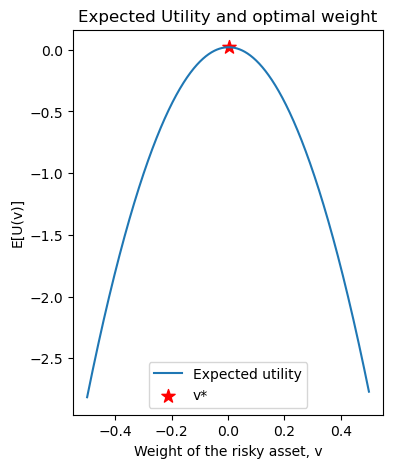

In [2]:
mu = 6.5/100
sigma2 = 90/100
R_f = 2/100
k = 25

# Define function to compute best weights for risky assets
def max_MV(mu, R_f, Sigma, k):
    mu_e = mu - R_f 
    w_star = 1/k * mu_e/Sigma
    w_rf = 1 - w_star 
    return w_star, w_rf


w_r, w_rf = max_MV(mu=mu, R_f=R_f, Sigma=sigma2, k = k)

# Evaluate E[U]
expUtility_max = (w_rf*R_f + w_r*mu) - k/2*w_r**2*sigma2
utility = lambda a : (R_f + a*(mu-R_f)) - 25/2*(a**2)*sigma2

w = np.linspace(-0.5,0.5,1000)
e_u = utility(w)

plt.figure(figsize=(4,5))
plt.plot(w,e_u, label = "Expected utility")
plt.scatter(w_r,expUtility_max, c='red', marker='*', s=100, label="v*")
plt.title("Expected Utility and optimal weight")
plt.ylabel("E[U(v)]")
plt.xlabel("Weight of the risky asset, v")
plt.legend()
plt.show()

## 5.2. Many Risky Assets and one Risk-free

Suppose an investor has mean-variance preferences:

$$ \max_{w} \mathbb{E}[R_p] + \frac{k}{2} \mathbb{V}[R_p] \qquad \text{ s.t. } R_p = w^T R^e + R_f $$

Hence the portfolio weights of the risky assets are:

$$ w^* = \frac{1}{k} \Sigma^{-1} \mu^e$$

And for the risk free is just $1 - \bold{1}^T w^*$. This is a generalization of the previous problem. The solution above is the same as for the case with only two assets in 5.1.

In [10]:
from utils import MeanVariance

# Define arrays
mu_a = np.array([8.5, 6.5])/100          
Sigma_a  = np.array([[166,34],[34,64]])/100**2
Rf_a = 3/100

# Define a MeanVariance object from the utils file
MV = MeanVariance(mu=mu_a,R_f = Rf_a, Sigma= Sigma_a)

# Set the risk aversion rate
risk_aversion = 9
MV.setk(k=risk_aversion)

w_star, w_rf = MV.maxExpUtility()
print("The optimal weights for the risky assets are: ", w_star)

# Check the weights 
print("The sum of the w is", w_star.sum() + w_rf)

# Compute mean and variance of the portfolio
mu_p, var_p = MV.meanAndVariance(w_star)

# compute the CML
mu_star = np.arange(0,0.10,0.01)
std, mu_star = MV.capitalMarketLine()

# get the tangent portfolio
w_T = MV.tangentPortfolio()
mu_T, var_T = MV.meanAndVariance(w=w_T)

The optimal weights for the risky assets are:  [0.27343567 0.46237619]
The sum of the w is 1.0


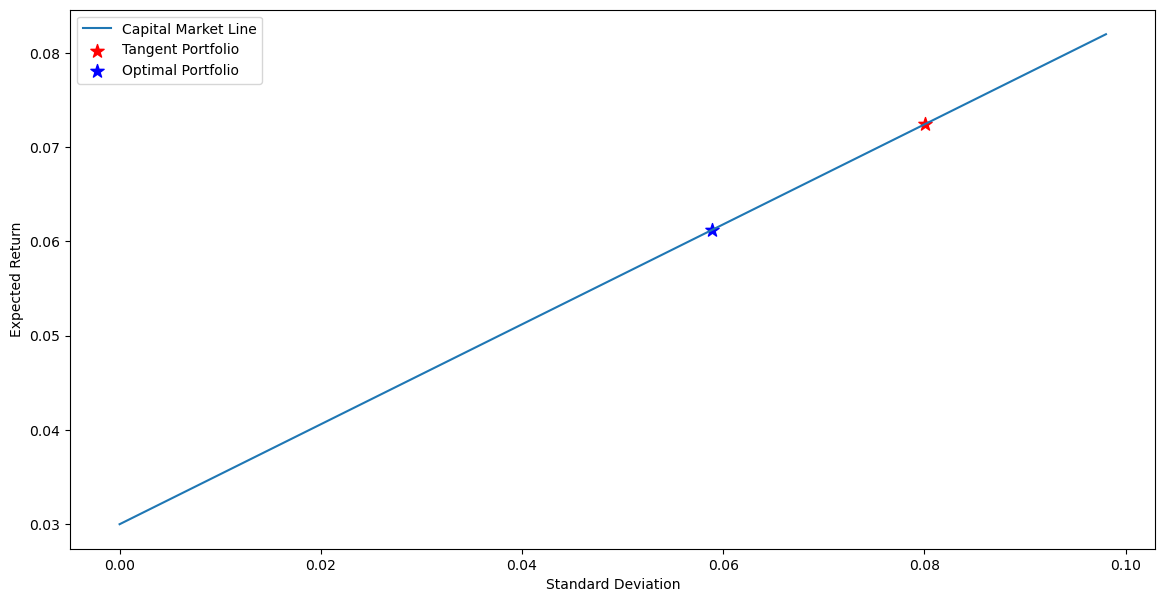

In [11]:
# plot
plt.figure(figsize=(14,7))
plt.plot(std, mu_star, label = "Capital Market Line")
plt.scatter(np.sqrt(var_T), mu_T, c='red', marker='*', s=100, label="Tangent Portfolio")
plt.scatter(np.sqrt(var_p), mu_p, c='blue', marker='*', s=100, label="Optimal Portfolio")
plt.ylabel("Expected Return")
plt.xlabel("Standard Deviation")
plt.legend()
plt.show()

## 5.3. The optimal portfolio is a linear combination of the Tangent portfolio

One can see very easily that the optimal portfolio is just proportional to the tangent portfolio:

$$ v = cw_T \qquad c = \frac{\bold{1}' \Sigma^{-1} \mu^{e}}{k} $$

Hence we just need to invest $ c $ in the tangent portfolio and $1-c$ in the risk-free rate. 

$$ R_p^* = cR^e_T + R_f $$

Therefore the beta of the portfolio is $\beta^* = c$. 